In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pickle,os

In [2]:
df=pd.read_csv(r'C:\Users\Madih\OneDrive\Documents\aicw\car_price_prediction\data\cleaned_dataset.csv')

In [3]:
df.shape

(725, 6)

In [4]:
df

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,80000,45000,Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,425000,40,Diesel
2,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,325000,28000,Petrol
3,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,575000,36000,Diesel
4,Ford Figo,Ford,2012,175000,41000,Diesel
...,...,...,...,...,...,...
720,Maruti Suzuki Ritz VXI ABS,Maruti,2011,270000,50000,Petrol
721,Tata Indica V2 DLE BS III,Tata,2009,110000,30000,Diesel
722,Toyota Corolla Altis,Toyota,2009,300000,132000,Petrol
723,Tata Zest XM Diesel,Tata,2018,260000,27000,Diesel


In [5]:
Reference_age=2026
df['car_age']=Reference_age-df['year']
df=df.drop('year',axis=1)

In [6]:
df

,name,company,Price,kms_driven,fuel_type,car_age
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,80000,45000,Petrol,19
1,Mahindra Jeep CL550 MDI,Mahindra,425000,40,Diesel,20
2,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,325000,28000,Petrol,12
3,Ford EcoSport Titanium 1.5L TDCi,Ford,575000,36000,Diesel,12
4,Ford Figo,Ford,175000,41000,Diesel,14
...,...,...,...,...,...,...
720,Maruti Suzuki Ritz VXI ABS,Maruti,270000,50000,Petrol,15
721,Tata Indica V2 DLE BS III,Tata,110000,30000,Diesel,17
722,Toyota Corolla Altis,Toyota,300000,132000,Petrol,17
723,Tata Zest XM Diesel,Tata,260000,27000,Diesel,8


In [7]:
df['car_age'].corr(df['Price'])

np.float64(-0.36399775621276564)

<Axes: ylabel='Price'>

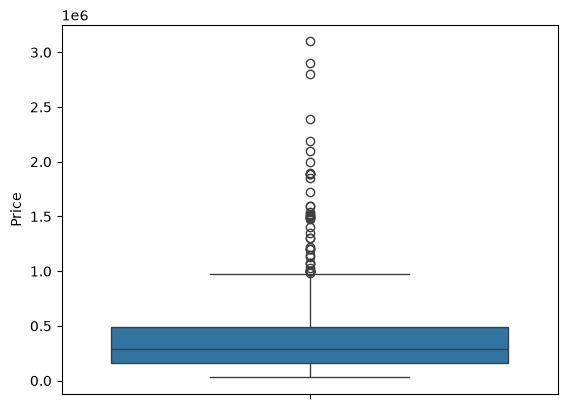

In [8]:
sns.boxplot(df['Price'])

<Axes: xlabel='Price', ylabel='Count'>

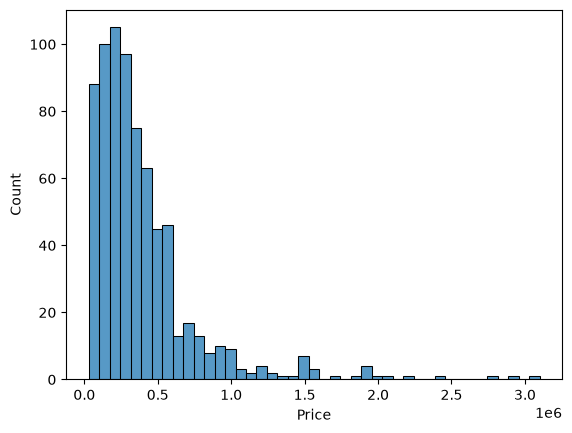

In [11]:
sns.histplot(df['Price'])

In [12]:
print(np.log(30000))

10.308952660644293


In [13]:
print(np.log(300000))

12.611537753638338


In [14]:
print(np.log(3000000))

14.914122846632385


In [17]:
lr_model = LinearRegression()
lr_model.fit(x_train, y_train)

lr_preds_log = lr_model.predict(x_test)
lr_results = evaluate_model('Linear Regression', y_orig_test, lr_preds_log)
all_results.append(lr_results)

# Show sample predictions
print('\nSample — Actual vs Predicted:')
sample_idx = range(5)
for i in sample_idx:
    actual = y_orig_test.values[i]
    predicted = np.exp(lr_preds_log[i])
    error = abs(actual - predicted)
    print(f'  Actual ₹{actual:>8,.0f}  |  Predicted ₹{predicted:>8,.0f}  |  Error ₹{error:>7,.0f}')

NameError: name 'LinearRegression' is not defined

In [15]:
df['log_price']=np.log(df['Price'])

In [18]:
df

,name,company,Price,kms_driven,fuel_type,car_age,log_price
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,80000,45000,Petrol,19,11.289782
1,Mahindra Jeep CL550 MDI,Mahindra,425000,40,Diesel,20,12.959844
2,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,325000,28000,Petrol,12,12.691580
3,Ford EcoSport Titanium 1.5L TDCi,Ford,575000,36000,Diesel,12,13.262125
4,Ford Figo,Ford,175000,41000,Diesel,14,12.072541
...,...,...,...,...,...,...,...
720,Maruti Suzuki Ritz VXI ABS,Maruti,270000,50000,Petrol,15,12.506177
721,Tata Indica V2 DLE BS III,Tata,110000,30000,Diesel,17,11.608236
722,Toyota Corolla Altis,Toyota,300000,132000,Petrol,17,12.611538
723,Tata Zest XM Diesel,Tata,260000,27000,Diesel,8,12.468437


In [19]:
df.drop('name',axis=1)

,company,Price,kms_driven,fuel_type,car_age,log_price
0,Hyundai,80000,45000,Petrol,19,11.289782
1,Mahindra,425000,40,Diesel,20,12.959844
2,Hyundai,325000,28000,Petrol,12,12.691580
3,Ford,575000,36000,Diesel,12,13.262125
4,Ford,175000,41000,Diesel,14,12.072541
...,...,...,...,...,...,...
720,Maruti,270000,50000,Petrol,15,12.506177
721,Tata,110000,30000,Diesel,17,11.608236
722,Toyota,300000,132000,Petrol,17,12.611538
723,Tata,260000,27000,Diesel,8,12.468437


In [20]:
df=pd.get_dummies(df,columns=['fuel_type','company'])

In [21]:
df

,name,Price,kms_driven,car_age,log_price,fuel_type_Diesel,fuel_type_LPG,fuel_type_Petrol,company_Audi,company_BMW,...,company_Mercedes,company_Mini,company_Mitsubishi,company_Nissan,company_Renault,company_Skoda,company_Tata,company_Toyota,company_Volkswagen,company_Volvo
0,Hyundai Santro Xing XO eRLX Euro III,80000,45000,19,11.289782,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,Mahindra Jeep CL550 MDI,425000,40,20,12.959844,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,Hyundai Grand i10 Magna 1.2 Kappa VTVT,325000,28000,12,12.691580,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
3,Ford EcoSport Titanium 1.5L TDCi,575000,36000,12,13.262125,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,Ford Figo,175000,41000,14,12.072541,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
720,Maruti Suzuki Ritz VXI ABS,270000,50000,15,12.506177,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
721,Tata Indica V2 DLE BS III,110000,30000,17,11.608236,True,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
722,Toyota Corolla Altis,300000,132000,17,12.611538,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
723,Tata Zest XM Diesel,260000,27000,8,12.468437,True,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False


In [22]:
bool_cols=df.select_dtypes(include='bool').columns

In [23]:
df[bool_cols]=df[bool_cols].astype(int)

In [24]:
x=df.drop(columns=['Price','log_price'])
y=df['log_price']
y_original=df['Price']

In [25]:
x.shape

(725, 31)

In [26]:
y.shape

(725,)

In [27]:
#traib_test_split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test,orig_train,y_orig_test=train_test_split(x,y,y_original,test_size=0.2,random_state=42)

In [28]:
#feature scaling
scaler= StandardScaler()
num_cols= ['car_age','kms_driven']
scaler.fit(x_train[num_cols])
x_train[num_cols]= scaler.transform(x_train[num_cols])
x_test[num_cols]= scaler.transform(x_test[num_cols])

In [29]:
os.makedirs('../artifacts', exist_ok=True)
 
feature_columns = x_train.columns.tolist()
company_list  = sorted([c.replace('company_','')   for c in feature_columns if c.startswith('company_')])
fuel_list     = sorted([c.replace('fuel_type_','') for c in feature_columns if c.startswith('fuel_type_')])
encoder_data  = {'company_list': company_list, 'fuel_type_list': fuel_list}
 
with open('../artifacts/scaler.pkl',  'wb') as f: pickle.dump(scaler, f)
with open('../artifacts/columns.pkl', 'wb') as f: pickle.dump(feature_columns, f)
with open('../artifacts/encoder.pkl', 'wb') as f: pickle.dump(encoder_data, f)
 
# Save processed data for Notebook 3
x_train.to_csv('../data/X_train.csv', index=False)
x_test.to_csv('../data/X_test.csv',   index=False)
y_train.to_csv('../data/y_train.csv', index=False)          # log scale
y_test.to_csv('../data/y_test.csv',   index=False)           # log scale
y_orig_test.to_csv('../data/y_orig_test.csv', index=False)  # INR scale — for evaluation
 
print('Artifacts saved:')
print(f'  scaler.pkl  — StandardScaler on car_age & kms_driven')
print(f'  columns.pkl — {len(feature_columns)} features')
print(f'  encoder.pkl — {len(company_list)} companies, {len(fuel_list)} fuel types')
print()
print('NOTE: y_train.csv contains log(Price). Notebook 3 must call np.exp() on predictions.')

Artifacts saved:
  scaler.pkl  — StandardScaler on car_age & kms_driven
  columns.pkl — 31 features
  encoder.pkl — 25 companies, 3 fuel types

NOTE: y_train.csv contains log(Price). Notebook 3 must call np.exp() on predictions.
